In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
import os

print(os.listdir('/content'))

['.config', 'sample_data']


In [12]:
import pandas as pd

df = pd.read_excel('/content/sample_data/AAPL.xlsx')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 9909
Columns: 7


In [13]:
df.head()


,Date,Open,High,Low,Close,Adj Close,Volume
0,29567,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,29570,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,29571,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,29572,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,29573,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


In [14]:
print(df.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   int64  
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(2)
memory usage: 542.0 KB


In [16]:
df['Date'] = pd.to_datetime(
    df['Date'],
    unit='D',
    origin='1899-12-30'
)

print("Date conversion completed!")
print(df['Date'].head())

Date conversion completed!
0   1980-12-12
1   1980-12-15
2   1980-12-16
3   1980-12-17
4   1980-12-18
Name: Date, dtype: datetime64[ns]


In [17]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())
print("Missing values:")
print(df.isnull().sum())

Start Date: 1980-12-12 00:00:00
End Date: 2020-04-01 00:00:00
Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


In [18]:
print("Duplicate rows:", df.duplicated().sum())
print("Dates sorted:", df['Date'].is_monotonic_increasing)

Duplicate rows: 0
Dates sorted: True


In [20]:
df = df.sort_values('Date').reset_index(drop=True)

In [21]:
print(df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].describe())

              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929     1.696429     1.732143     1.466154   
75%      35.799999    36.265713    35.328571    35.761429    31.042374   
max     324.739990   327.850006   323.350006   327.200012   327.200012   

             Volume  
count  9.909000e+03  
mean   8.582916e+07  
std    8.597195e+07  
min    3.472000e+05  
25%    3.304230e+07  
50%    5.766490e+07  
75%    1.069992e+08  
max    1.855410e+09  


In [22]:
df_clean = df.copy()

print("Clean dataset shape:", df_clean.shape)

Clean dataset shape: (9909, 7)


In [24]:

print("Date data type:", df['Date'].dtype)
print("First 5 dates:")
print(df['Date'].head())

Date data type: datetime64[ns]
First 5 dates:
0   1980-12-12
1   1980-12-15
2   1980-12-16
3   1980-12-17
4   1980-12-18
Name: Date, dtype: datetime64[ns]


In [25]:
# Sort data by date
df = df.sort_values('Date').reset_index(drop=True)

print("Data sorted successfully!")
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

print("Missing values:")
print(df.isnull().sum())

print("Duplicate rows:", df.duplicated().sum())

print("Dates sorted correctly:", df['Date'].is_monotonic_increasing)

print(df[['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']].describe())

Data sorted successfully!
Start Date: 1980-12-12 00:00:00
End Date: 2020-04-01 00:00:00
Missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64
Duplicate rows: 0
Dates sorted correctly: True
              Open         High          Low        Close    Adj Close  \
count  9909.000000  9909.000000  9909.000000  9909.000000  9909.000000   
mean     32.606849    32.936079    32.277560    32.618030    30.576570   
std      58.415759    59.001576    57.883037    58.471899    56.746275   
min       0.198661     0.198661     0.196429     0.196429     0.155638   
25%       1.071429     1.089286     1.048571     1.071429     0.917643   
50%       1.729286     1.758929     1.696429     1.732143     1.466154   
75%      35.799999    36.265713    35.328571    35.761429    31.042374   
max     324.739990   327.850006   323.350006   327.200012   327.200012   

             Volume  
count  9.909000e+03  
mean   8.582916e+07 

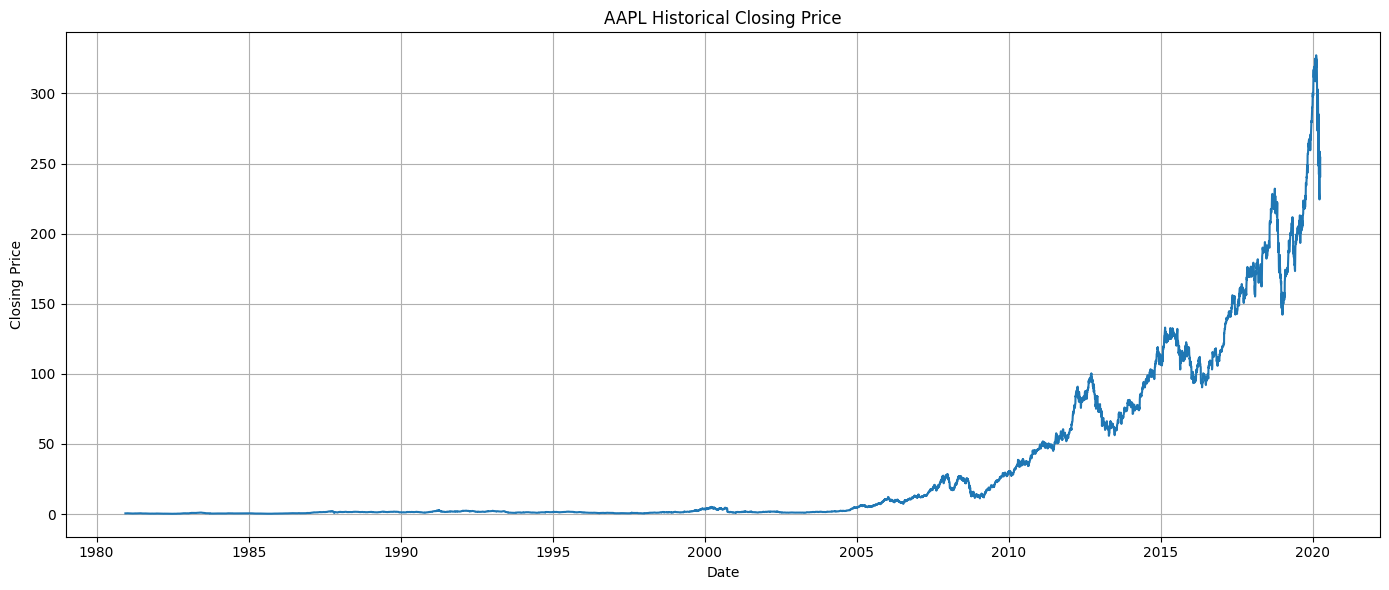

In [26]:
# EDA 1: Historical Closing Price

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Close'])

plt.title('AAPL Historical Closing Price')
plt.xlabel('Date')
plt.ylabel('Closing Price')

plt.grid(True)
plt.tight_layout()
plt.show()

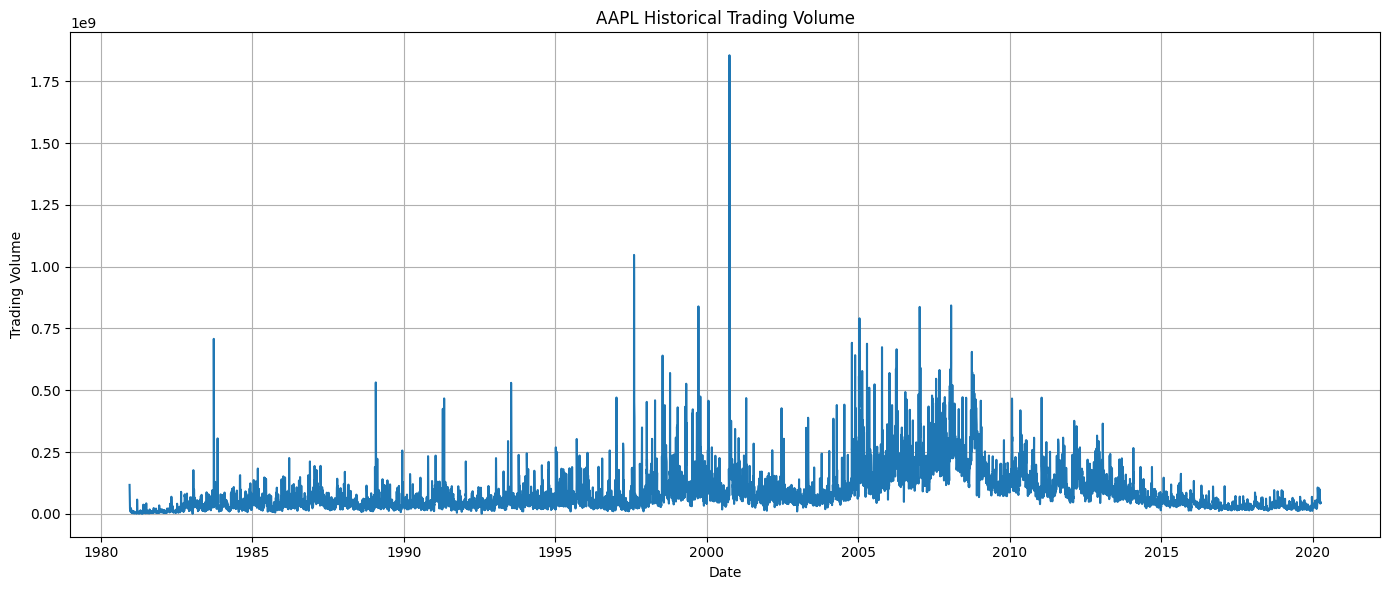

In [27]:
# EDA 2: Trading Volume

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Volume'])

plt.title('AAPL Historical Trading Volume')
plt.xlabel('Date')
plt.ylabel('Trading Volume')

plt.grid(True)
plt.tight_layout()
plt.show()

In [28]:
# Calculate daily returns

df['Return'] = df['Close'].pct_change()

print(df[['Date', 'Close', 'Return']].head(10))

        Date     Close    Return
0 1980-12-12  0.513393       NaN
1 1980-12-15  0.486607 -0.052174
2 1980-12-16  0.450893 -0.073394
3 1980-12-17  0.462054  0.024752
4 1980-12-18  0.475446  0.028986
5 1980-12-19  0.504464  0.061033
6 1980-12-22  0.529018  0.048673
7 1980-12-23  0.551339  0.042194
8 1980-12-24  0.580357  0.052632
9 1980-12-26  0.633929  0.092308


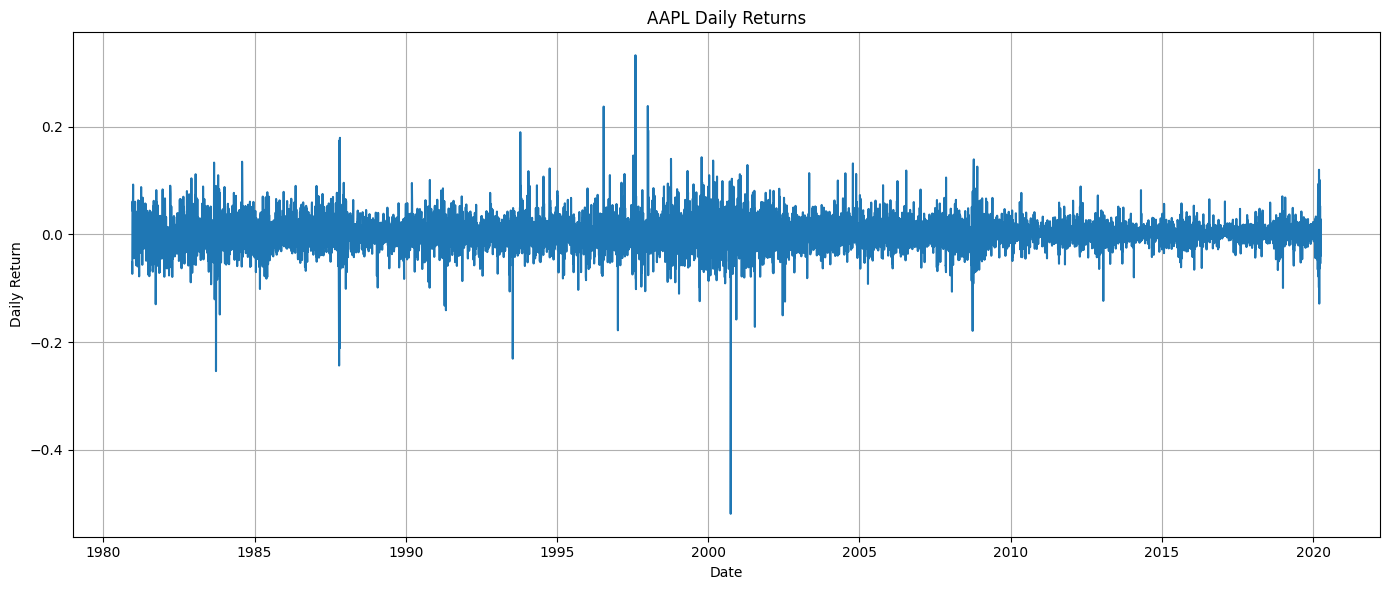

In [29]:
# EDA 3: Daily Returns

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Return'])

plt.title('AAPL Daily Returns')
plt.xlabel('Date')
plt.ylabel('Daily Return')

plt.grid(True)
plt.tight_layout()
plt.show()

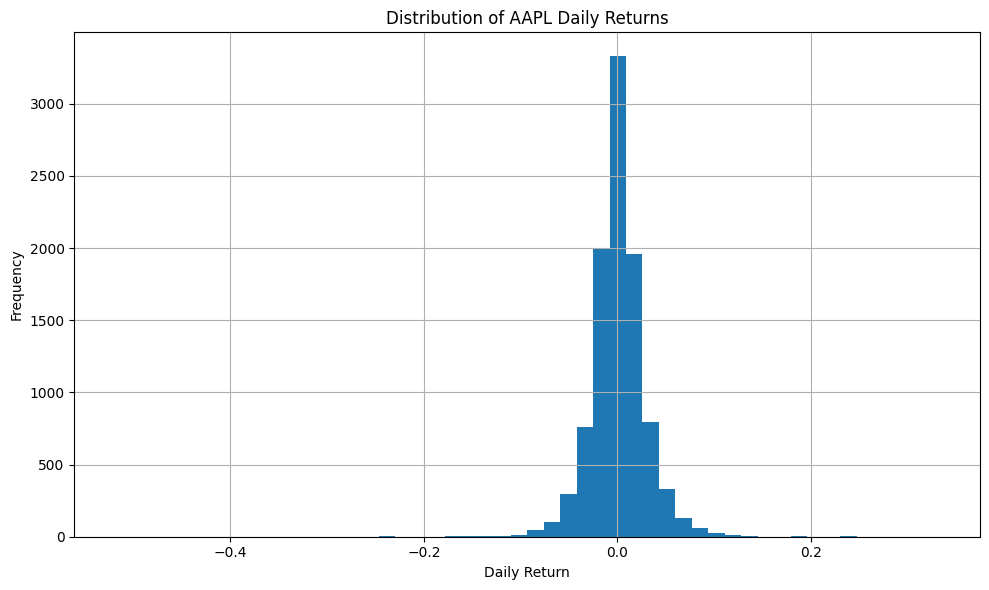

In [30]:
# EDA 4: Distribution of Daily Returns

plt.figure(figsize=(10, 6))

plt.hist(
    df['Return'].dropna(),
    bins=50
)

plt.title('Distribution of AAPL Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.grid(True)
plt.tight_layout()
plt.show()

In [31]:
# Calculate 20-day rolling volatility

df['Volatility_20'] = df['Return'].rolling(window=20).std()

print(df[['Date', 'Return', 'Volatility_20']].tail(10))

           Date    Return  Volatility_20
9899 2020-03-19 -0.007662       0.062726
9900 2020-03-20 -0.063486       0.063765
9901 2020-03-23 -0.021244       0.063297
9902 2020-03-24  0.100325       0.067831
9903 2020-03-25 -0.005509       0.067645
9904 2020-03-26  0.052623       0.067392
9905 2020-03-27 -0.041402       0.068004
9906 2020-03-30  0.028538       0.064667
9907 2020-03-31 -0.002041       0.064383
9908 2020-04-01 -0.052617       0.064074


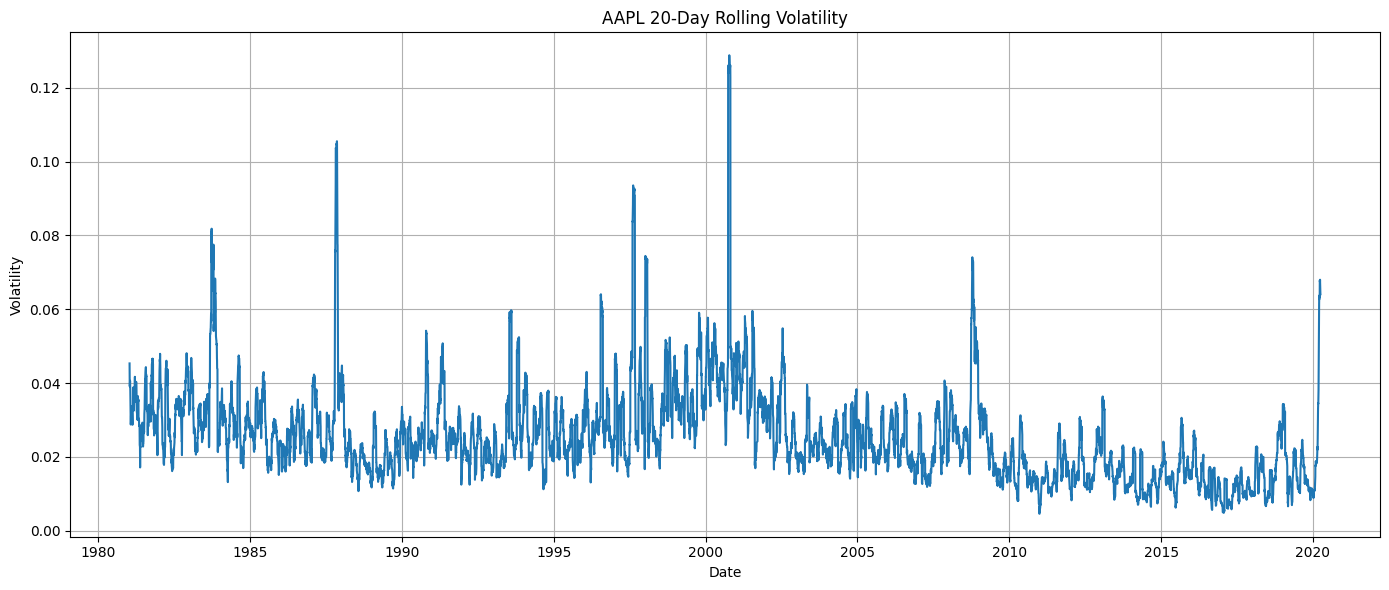

In [32]:
# EDA 5: 20-Day Rolling Volatility

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Volatility_20'])

plt.title('AAPL 20-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Volatility')

plt.grid(True)
plt.tight_layout()
plt.show()

In [33]:
# Save processed EDA dataset

df.to_csv(
    '/content/AAPL_EDA.csv',
    index=False
)

print("EDA dataset saved successfully!")

EDA dataset saved successfully!


In [34]:
# STEP 4.1 - Moving Averages

df['MA10'] = df['Close'].rolling(window=10).mean()
df['MA20'] = df['Close'].rolling(window=20).mean()
df['MA50'] = df['Close'].rolling(window=50).mean()

print("Moving averages created successfully!")

print(df[['Date', 'Close', 'MA10', 'MA20', 'MA50']].tail())

Moving averages created successfully!
           Date       Close        MA10        MA20      MA50
9904 2020-03-26  258.440002  246.894002  264.514500  294.6510
9905 2020-03-27  247.740005  243.871002  263.233501  293.3790
9906 2020-03-30  254.809998  245.131001  261.033501  292.1704
9907 2020-03-31  254.289993  245.274001  259.282001  290.8816
9908 2020-04-01  240.910004  244.698001  256.190501  289.3684


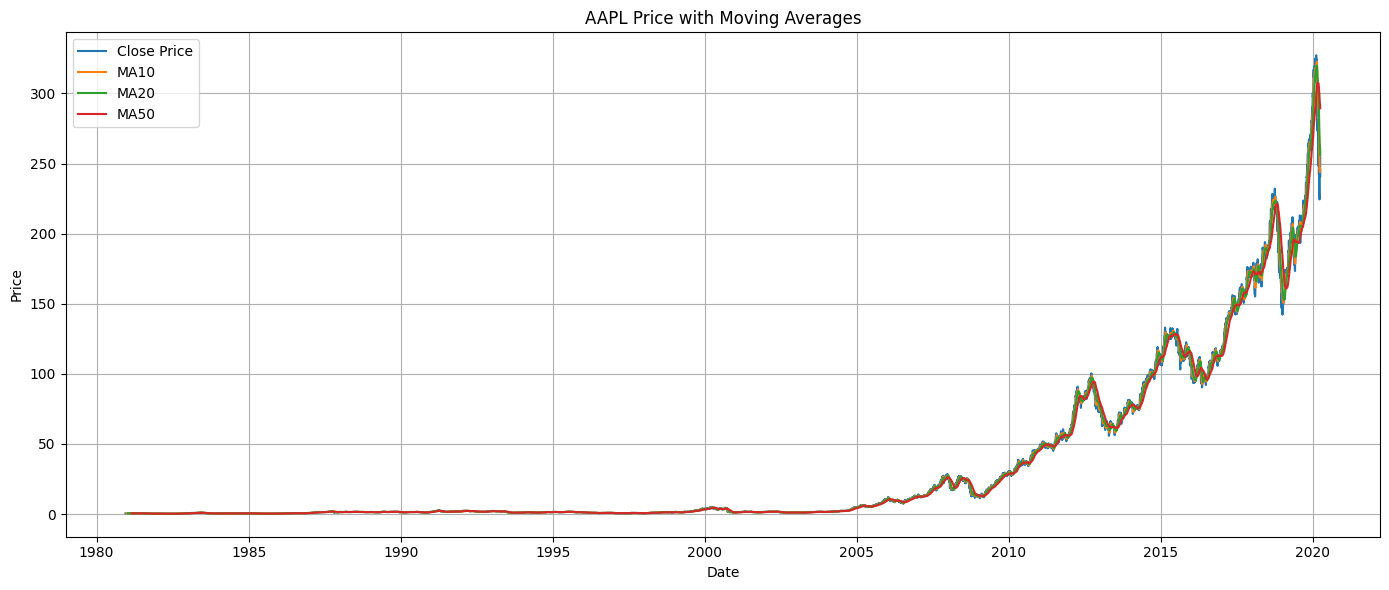

In [35]:
# STEP 4.2 - Moving Average Visualization

plt.figure(figsize=(14, 6))

plt.plot(df['Date'], df['Close'], label='Close Price')
plt.plot(df['Date'], df['MA10'], label='MA10')
plt.plot(df['Date'], df['MA20'], label='MA20')
plt.plot(df['Date'], df['MA50'], label='MA50')

plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [36]:
# STEP 4.3 - RSI Calculation

delta = df['Close'].diff()

gain = delta.clip(lower=0)
loss = -delta.clip(upper=0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI14'] = 100 - (100 / (1 + rs))

print("RSI created successfully!")

print(df[['Date', 'Close', 'RSI14']].tail())

RSI created successfully!
           Date       Close      RSI14
9904 2020-03-26  258.440002  43.065694
9905 2020-03-27  247.740005  45.578425
9906 2020-03-30  254.809998  42.224034
9907 2020-03-31  254.289993  44.345175
9908 2020-04-01  240.910004  47.885617


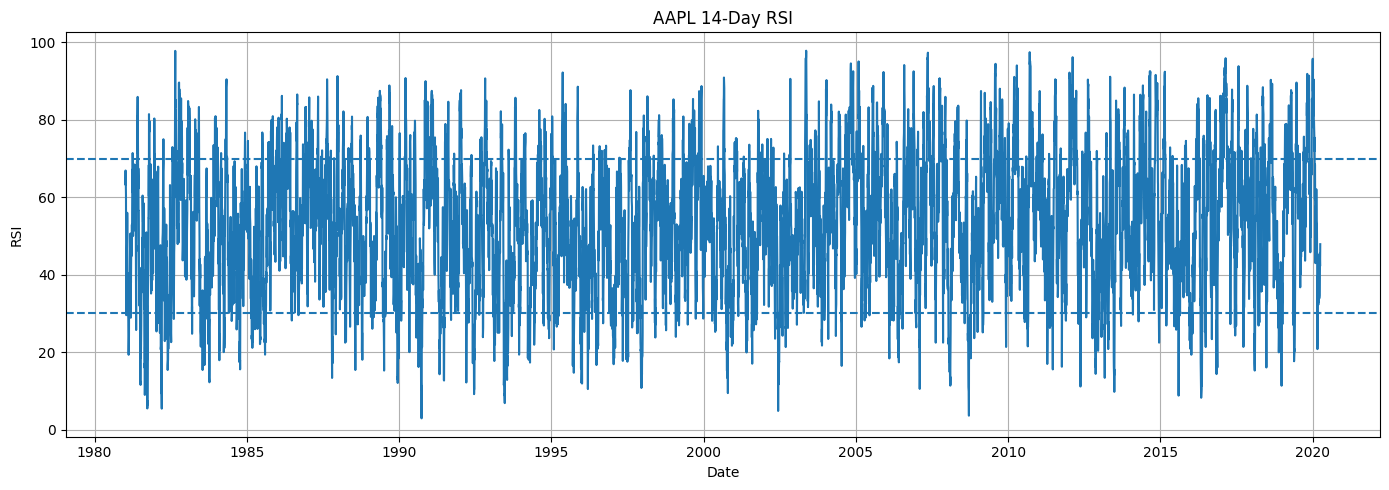

In [37]:
# STEP 4.4 - RSI Visualization

plt.figure(figsize=(14, 5))

plt.plot(df['Date'], df['RSI14'])

plt.axhline(70, linestyle='--')
plt.axhline(30, linestyle='--')

plt.title('AAPL 14-Day RSI')
plt.xlabel('Date')
plt.ylabel('RSI')

plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
# STEP 4.5 - Additional Features

df['High_Low_Range'] = df['High'] - df['Low']

df['Open_Close_Diff'] = df['Close'] - df['Open']

df['Volume_Change'] = df['Volume'].pct_change()

print("Additional features created successfully!")

Additional features created successfully!


In [39]:
# Check engineered features

feature_columns = [
    'Close',
    'Return',
    'MA10',
    'MA20',
    'MA50',
    'RSI14',
    'Volatility_20',
    'High_Low_Range',
    'Open_Close_Diff',
    'Volume_Change'
]

df[feature_columns].tail(10)

,Close,Return,MA10,MA20,MA50,RSI14,Volatility_20,High_Low_Range,Open_Close_Diff,Volume_Change
9899,244.779999,-0.007662,262.869000,277.565997,301.617799,43.661286,0.062726,10.229996,-2.610001,-0.094514
9900,229.240005,-0.063486,256.890001,273.375498,300.138799,33.860711,0.063765,23.830002,-17.939987,0.477589
9901,224.369995,-0.021244,252.709999,269.684998,298.433599,34.602430,0.063297,15.889999,-3.710007,-0.161667
9902,246.880005,0.100325,248.864000,267.624999,297.164599,37.304547,0.067831,13.389999,10.520004,-0.146165
9903,245.520004,-0.005509,245.873001,265.268500,295.735800,38.796443,0.067645,13.949997,-5.229996,0.055892
9904,258.440002,0.052623,246.894002,264.514500,294.651000,43.065694,0.067392,12.319992,11.919998,-0.169679
9905,247.740005,-0.041402,243.871002,263.233501,293.379000,45.578425,0.068004,8.819992,-5.009995,-0.189896
9906,254.809998,0.028538,245.131001,261.033501,292.170400,42.224034,0.064667,6.120010,4.069992,-0.177460
9907,254.289993,-0.002041,245.274001,259.282001,290.881600,44.345175,0.064383,10.489990,-1.310013,0.172796
9908,240.910004,-0.052617,244.698001,256.190501,289.368400,47.885617,0.064074,9.589996,-5.589996,-0.107497


In [40]:
# Check missing values after feature engineering

print(df[feature_columns].isnull().sum())

Close               0
Return              1
MA10                9
MA20               19
MA50               49
RSI14              14
Volatility_20      20
High_Low_Range      0
Open_Close_Diff     0
Volume_Change       1
dtype: int64


In [41]:
# STEP 4.8 - Create Prediction Target

df['Tomorrow_Close'] = df['Close'].shift(-1)

df['Target'] = (
    df['Tomorrow_Close'] > df['Close']
).astype(int)

print(df[['Date', 'Close', 'Tomorrow_Close', 'Target']].tail(10))

           Date       Close  Tomorrow_Close  Target
9899 2020-03-19  244.779999      229.240005       0
9900 2020-03-20  229.240005      224.369995       0
9901 2020-03-23  224.369995      246.880005       1
9902 2020-03-24  246.880005      245.520004       0
9903 2020-03-25  245.520004      258.440002       1
9904 2020-03-26  258.440002      247.740005       0
9905 2020-03-27  247.740005      254.809998       1
9906 2020-03-30  254.809998      254.289993       0
9907 2020-03-31  254.289993      240.910004       0
9908 2020-04-01  240.910004             NaN       0


In [42]:
# Check target distribution

print(df['Target'].value_counts())

print("\nTarget percentages:")
print(df['Target'].value_counts(normalize=True) * 100)

Target
0    5019
1    4890
Name: count, dtype: int64

Target percentages:
Target
0    50.650923
1    49.349077
Name: proportion, dtype: float64


In [43]:
# Remove rows with missing values

df_model = df.dropna().copy()

print("Original rows:", len(df))
print("Rows available for modeling:", len(df_model))

Original rows: 9909
Rows available for modeling: 9859


In [45]:
print(df_model.shape)

(9859, 18)


In [46]:
print(df_model.columns.tolist())

['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Return', 'Volatility_20', 'MA10', 'MA20', 'MA50', 'RSI14', 'High_Low_Range', 'Open_Close_Diff', 'Volume_Change', 'Tomorrow_Close', 'Target']


In [47]:
df_model.head()

,Date,Open,High,Low,Close,Adj Close,Volume,Return,Volatility_20,MA10,MA20,MA50,RSI14,High_Low_Range,Open_Close_Diff,Volume_Change,Tomorrow_Close,Target
49,1981-02-24,0.428571,0.428571,0.424107,0.424107,0.336037,4244800,-0.035533,0.033942,0.458705,0.487054,0.530312,31.325304,0.004464,-0.004464,0.203175,0.450893,1
50,1981-02-25,0.450893,0.453125,0.450893,0.450893,0.357260,4872000,0.063158,0.038142,0.455134,0.481027,0.529062,34.482759,0.002232,0.000000,0.147757,0.457589,1
51,1981-02-26,0.457589,0.459821,0.457589,0.457589,0.362566,2710400,0.014851,0.038252,0.453795,0.476228,0.528482,36.666668,0.002232,0.000000,-0.443678,0.473214,1
52,1981-02-27,0.473214,0.477679,0.473214,0.473214,0.374946,3690400,0.034146,0.038824,0.454464,0.473214,0.528929,40.625003,0.004464,0.000000,0.361570,0.475446,1
53,1981-03-02,0.475446,0.477679,0.475446,0.475446,0.376715,2940000,0.004717,0.037098,0.456473,0.471763,0.529196,47.058827,0.002232,0.000000,-0.203338,0.468750,0


In [59]:
# STEP 5.1 - Define Features

features = [
    'Close',
    'Return',
    'MA10',
    'MA20',
    'MA50',
    'RSI14',
    'Volatility_20',
    'High_Low_Range',
    'Open_Close_Diff',
    'Volume_Change'
]

X = df_model[features]
y = df_model['Target']

print("Number of features:", len(features))
print("Feature names:")
print(features)

Number of features: 10
Feature names:
['Close', 'Return', 'MA10', 'MA20', 'MA50', 'RSI14', 'Volatility_20', 'High_Low_Range', 'Open_Close_Diff', 'Volume_Change']


In [60]:
# STEP 5.2 - Chronological Train/Test Split

split_index = int(len(df_model) * 0.80)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 7887
Testing samples: 1972


In [61]:
# Verify chronological split

train_dates = df_model['Date'].iloc[:split_index]
test_dates = df_model['Date'].iloc[split_index:]

print("Training period:")
print(train_dates.min(), "to", train_dates.max())

print("\nTesting period:")
print(test_dates.min(), "to", test_dates.max())

Training period:
1981-02-24 00:00:00 to 2012-05-29 00:00:00

Testing period:
2012-05-30 00:00:00 to 2020-03-31 00:00:00


In [62]:
# STEP 6 - Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Training shape: (7887, 10)
Testing shape: (1972, 10)


In [52]:
# STEP 7.1 - Logistic Regression

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [53]:
# STEP 8 - Predictions

y_pred_logistic = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print(y_pred_logistic[:20])

Predictions generated successfully!
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [54]:
# STEP 9 - Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

print("Logistic Regression Results")
print("----------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Results
----------------------------
Accuracy : 0.5273833671399595
Precision: 0.5253063399041022
Recall   : 0.9600778967867576
F1 Score : 0.6790633608815427

Classification Report:
              precision    recall  f1-score   support

           0       0.57      0.06      0.10       945
           1       0.53      0.96      0.68      1027

    accuracy                           0.53      1972
   macro avg       0.55      0.51      0.39      1972
weighted avg       0.55      0.53      0.40      1972



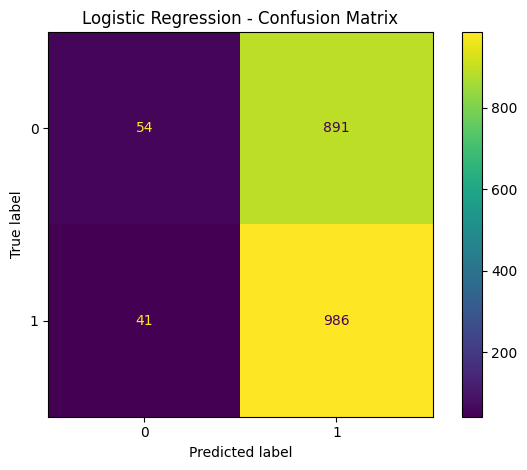

In [55]:
# STEP 10 - Confusion Matrix

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_logistic
)

plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()
plt.show()

In [56]:
 #STEP 11 - Random Forest

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [57]:
# Random Forest Predictions

y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated!")
print(y_pred_rf[:20])

Random Forest predictions generated!
[1 1 1 1 1 1 1 0 1 1 1 1 0 1 0 0 0 0 0 0]


In [ ]:
# Random Forest Evaluation

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

In [64]:
# STEP 7 - Train Logistic Regression Model

from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [65]:
# STEP 8 - Make Predictions

y_pred_lr = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred_lr))
print("First 20 predictions:")
print(y_pred_lr[:20])

Predictions generated successfully!
Number of predictions: 1972
First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [66]:
# STEP 9 - Evaluate Logistic Regression Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, zero_division=0)
recall_lr = recall_score(y_test, y_pred_lr, zero_division=0)
f1_lr = f1_score(y_test, y_pred_lr, zero_division=0)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", accuracy_lr)
print("Precision:", precision_lr)
print("Recall   :", recall_lr)
print("F1 Score :", f1_lr)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression Results
---------------------------
Accuracy : 0.5273833671399595
Precision: 0.5253063399041022
Recall   : 0.9600778967867576
F1 Score : 0.6790633608815427

Confusion Matrix:
[[ 54 891]
 [ 41 986]]


In [67]:
# STEP 10 - Train Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_scaled, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [68]:
# STEP 11 - Make Random Forest Predictions

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest predictions generated successfully!")
print("Number of predictions:", len(y_pred_rf))
print("First 20 predictions:")
print(y_pred_rf[:20])

Random Forest predictions generated successfully!
Number of predictions: 1972
First 20 predictions:
[1 1 1 1 1 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0]


In [69]:
# STEP 12 - Evaluate Random Forest Model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, zero_division=0)
recall_rf = recall_score(y_test, y_pred_rf, zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, zero_division=0)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.47971602434077076
Precision: 0.5014084507042254
Recall   : 0.1733203505355404
F1 Score : 0.2575976845151954

Confusion Matrix:
[[768 177]
 [849 178]]


In [70]:
# STEP 13 - Compare Models

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_rf
    ]
})

print("Model Comparison")
print("================")
print(comparison.to_string(index=False))

print("\nPercentages:")
comparison_percent = comparison.copy()
comparison_percent.iloc[:, 1:] = comparison_percent.iloc[:, 1:] * 100
print(comparison_percent.to_string(index=False))

Model Comparison
              Model  Accuracy  Precision   Recall  F1 Score
Logistic Regression  0.527383   0.525306 0.960078  0.679063
      Random Forest  0.479716   0.501408 0.173320  0.257598

Percentages:
              Model  Accuracy  Precision    Recall  F1 Score
Logistic Regression 52.738337  52.530634 96.007790 67.906336
      Random Forest 47.971602  50.140845 17.332035 25.759768


Logistic Regression AUC: 0.5230357078458344
Random Forest AUC: 0.4853763208193588


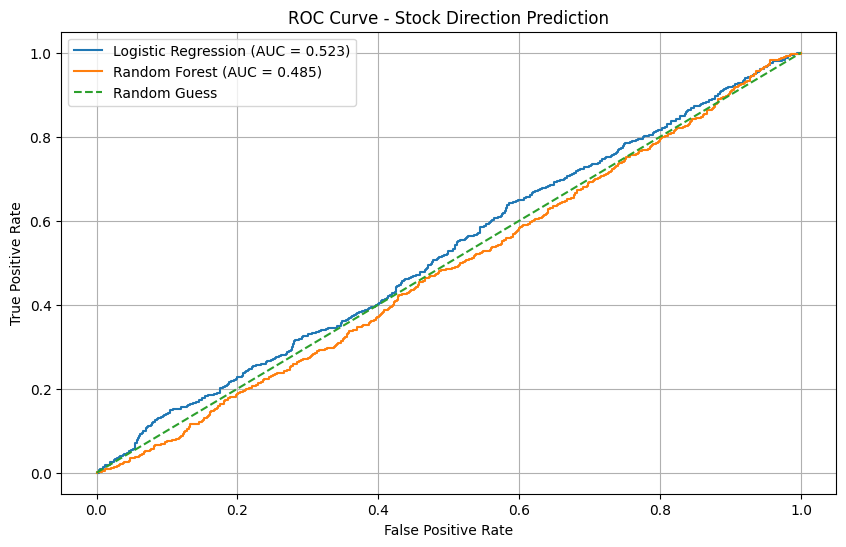

In [71]:
# STEP 14 - ROC Curve and AUC

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get probability scores
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Calculate ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# Calculate AUC
auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression AUC:", auc_lr)
print("Random Forest AUC:", auc_rf)

# Plot ROC curves
plt.figure(figsize=(10, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stock Direction Prediction")
plt.legend()
plt.grid(True)

plt.show()

Feature Importance:
        Feature  Importance
  Volume_Change    0.113149
         Return    0.111561
  Volatility_20    0.106504
          RSI14    0.102091
          Close    0.098611
 High_Low_Range    0.095490
Open_Close_Diff    0.094455
           MA10    0.094073
           MA50    0.092168
           MA20    0.091897


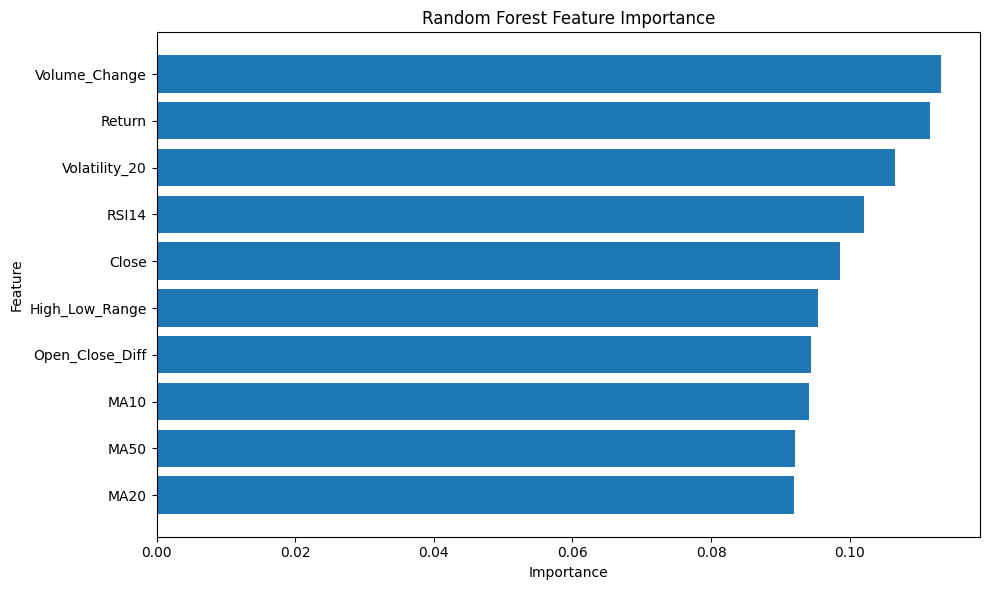

In [72]:
# STEP 15 - Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
print(feature_importance.to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Actual vs Predicted Results:
    Actual  Logistic Regression  Random Forest
0        0                    1              1
1        0                    1              1
2        1                    1              1
3        0                    1              1
4        1                    1              1
5        1                    1              1
6        1                    1              1
7        0                    1              0
8        1                    1              1
9        0                    1              0
10       0                    1              0
11       1                    1              1
12       1                    1              0
13       1                    1              1
14       0                    1              0
15       0                    1              0
16       1                    1              0
17       0                    1              0
18       1                    1              0
19       1                    1

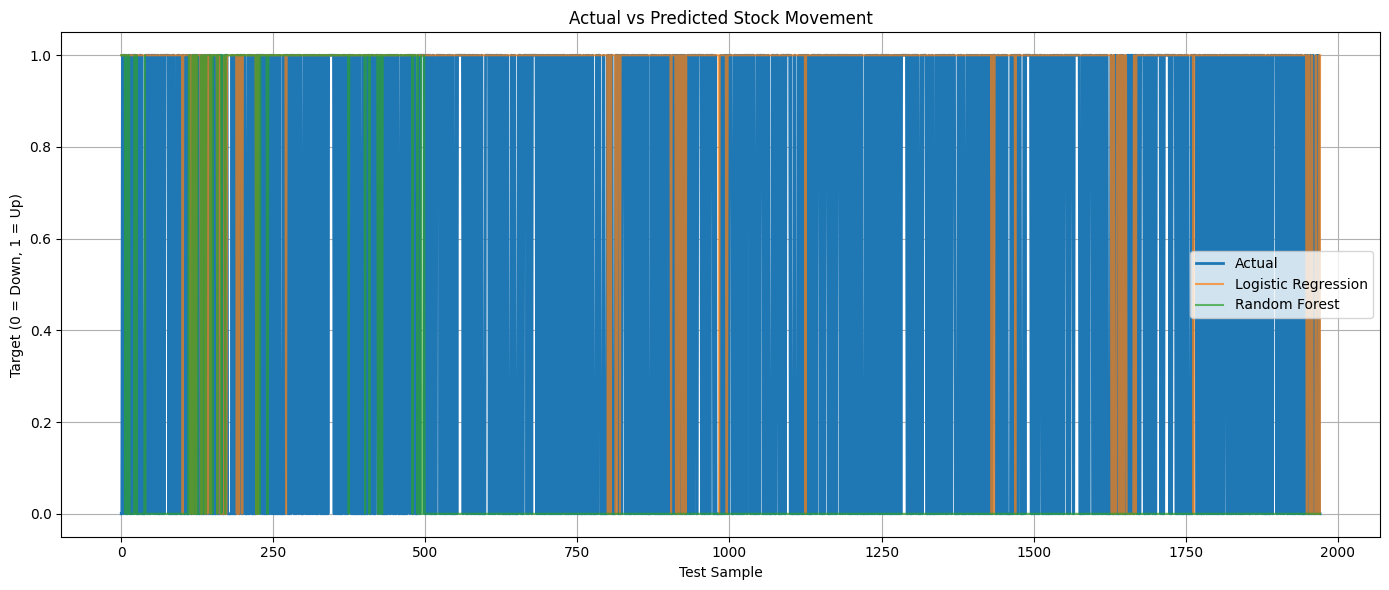

In [73]:
# STEP 16 - Actual vs Predicted Results

import matplotlib.pyplot as plt
import numpy as np

# Create a comparison DataFrame
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf
})

# Display first 20 predictions
print("Actual vs Predicted Results:")
print(comparison.head(20))

# Plot comparison
plt.figure(figsize=(14, 6))

plt.plot(
    comparison["Actual"].values,
    label="Actual",
    linewidth=2
)

plt.plot(
    comparison["Logistic Regression"].values,
    label="Logistic Regression",
    alpha=0.7
)

plt.plot(
    comparison["Random Forest"].values,
    label="Random Forest",
    alpha=0.7
)

plt.xlabel("Test Sample")
plt.ylabel("Target (0 = Down, 1 = Up)")
plt.title("Actual vs Predicted Stock Movement")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
# STEP 17 - Prediction Probabilities

# Get prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Display first 20 probabilities
print("Logistic Regression Prediction Probabilities:")
print(y_prob_lr[:20])

# Create comparison table
probability_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_lr,
    "Probability of Up": y_prob_lr
})

print("\nFirst 20 Prediction Results:")
print(probability_results.head(20))

Logistic Regression Prediction Probabilities:
[0.52271137 0.56331951 0.56375802 0.53571049 0.54318821 0.54583298
 0.57480755 0.53805317 0.60086841 0.55684191 0.56502826 0.55808271
 0.55427428 0.52384896 0.56489464 0.58272199 0.59231744 0.56729851
 0.58330066 0.56552337]

First 20 Prediction Results:
    Actual  Predicted  Probability of Up
0        0          1           0.522711
1        0          1           0.563320
2        1          1           0.563758
3        0          1           0.535710
4        1          1           0.543188
5        1          1           0.545833
6        1          1           0.574808
7        0          1           0.538053
8        1          1           0.600868
9        0          1           0.556842
10       0          1           0.565028
11       1          1           0.558083
12       1          1           0.554274
13       1          1           0.523849
14       0          1           0.564895
15       0          1           0.582722
16

ROC-AUC Results
AUC Score: 0.5230357078458344


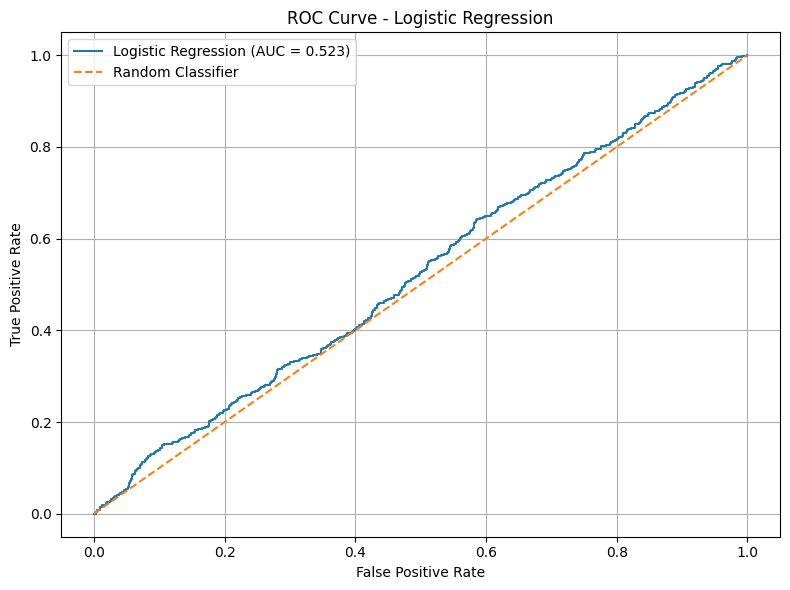

In [75]:
# STEP 18 - ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# Calculate AUC
auc_score = roc_auc_score(y_test, y_prob_lr)

print("ROC-AUC Results")
print("================")
print("AUC Score:", auc_score)

# Plot ROC Curve
plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [76]:
# STEP 19 - Final Model Performance Comparison

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_rf
    ]
})

# Add AUC values if they have already been calculated
auc_values = [
    auc_score,
    roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1])
]

final_comparison["AUC"] = auc_values

# Convert metrics to percentages for easier reading
display_table = final_comparison.copy()

for column in ["Accuracy", "Precision", "Recall", "F1 Score", "AUC"]:
    display_table[column] = (
        display_table[column] * 100
    ).round(2)

print("FINAL MODEL PERFORMANCE COMPARISON")
print("===================================")

display(display_table)

FINAL MODEL PERFORMANCE COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,AUC
0,Logistic Regression,52.74,52.53,96.01,67.91,52.30
1,Random Forest,47.97,50.14,17.33,25.76,48.54


In [77]:
# STEP 20.1 - Save Final Predictions

final_results = pd.DataFrame({
    'Date': df_model['Date'].iloc[split_index:].values,
    'Actual': y_test.values,
    'Logistic_Regression_Prediction': y_pred_lr,
    'Random_Forest_Prediction': y_pred_rf,
    'Logistic_Regression_Probability_Up': y_prob_lr
})

print("Final prediction dataset created!")
print("Rows:", len(final_results))

display(final_results.head(10))

Final prediction dataset created!
Rows: 1972


,Date,Actual,Logistic_Regression_Prediction,Random_Forest_Prediction,Logistic_Regression_Probability_Up
0,2012-05-30,0,1,1,0.522711
1,2012-05-31,0,1,1,0.563320
2,2012-06-01,1,1,1,0.563758
3,2012-06-04,0,1,1,0.535710
4,2012-06-05,1,1,1,0.543188
5,2012-06-06,1,1,1,0.545833
6,2012-06-07,1,1,1,0.574808
7,2012-06-08,0,1,0,0.538053
8,2012-06-11,1,1,1,0.600868
9,2012-06-12,0,1,0,0.556842


In [78]:
# STEP 20.2 - Save Predictions to CSV

final_results.to_csv(
    '/content/final_predictions.csv',
    index=False
)

print("final_predictions.csv saved successfully!")

final_predictions.csv saved successfully!


In [79]:
# STEP 20.3 - Save Model Comparison

final_comparison.to_csv(
    '/content/model_comparison.csv',
    index=False
)

print("model_comparison.csv saved successfully!")

model_comparison.csv saved successfully!


In [80]:
# STEP 20.4 - Save Processed Dataset

df_model.to_csv(
    '/content/AAPL_processed_dataset.csv',
    index=False
)

print("AAPL_processed_dataset.csv saved successfully!")

AAPL_processed_dataset.csv saved successfully!


In [82]:
 #STEP 20.5 - Check Project Output Files

import os

print("Project output files:")

for file in os.listdir('/content'):
    if file.endswith('.csv'):
        print(file)

Project output files:
final_predictions.csv
model_comparison.csv
AAPL_processed_dataset.csv
AAPL_EDA.csv


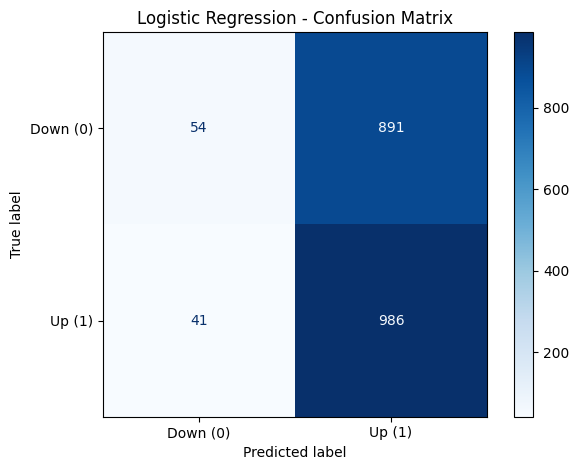

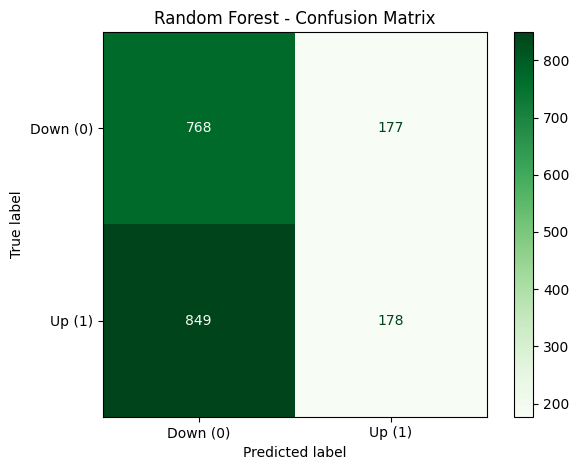

In [83]:
# STEP 21 - Confusion Matrix Visualization

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["Down (0)", "Up (1)"],
    cmap="Blues"
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()


# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["Down (0)", "Up (1)"],
    cmap="Greens"
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

Random Forest Feature Importance:


,Feature,Importance
9,Volume_Change,0.113149
1,Return,0.111561
6,Volatility_20,0.106504
5,RSI14,0.102091
0,Close,0.098611
7,High_Low_Range,0.095490
8,Open_Close_Diff,0.094455
2,MA10,0.094073
4,MA50,0.092168
3,MA20,0.091897


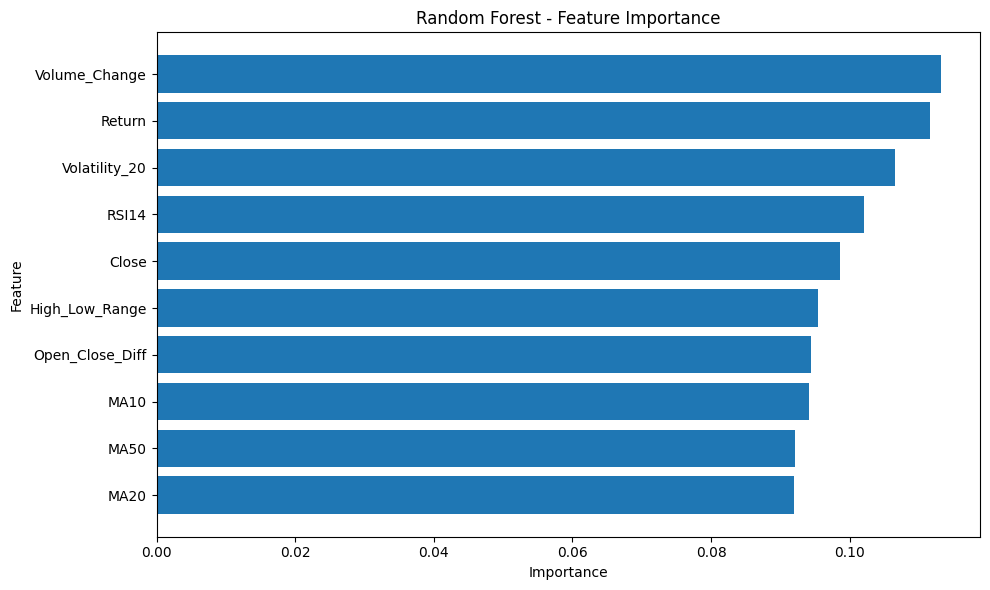

In [84]:
# STEP 22 - Feature Importance Visualization

import pandas as pd
import matplotlib.pyplot as plt

# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": rf_model.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

# Plot feature importance
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [86]:
# STEP 23 - Error Analysis

# Create error analysis table
error_analysis = pd.DataFrame({
    "Date": df_model["Date"].iloc[split_index:].values,
    "Actual": y_test.values,
    "Logistic_Prediction": y_pred_lr,
    "Random_Forest_Prediction": y_pred_rf
})
# Identify incorrect predictions
error_analysis["LR_Error"] = (
    error_analysis["Actual"] != error_analysis["Logistic_Prediction"]
)
error_analysis["RF_Error"] = (
    error_analysis["Actual"] != error_analysis["Random_Forest_Prediction"]
)
# Count errors
lr_errors = error_analysis["LR_Error"].sum()
rf_errors = error_analysis["RF_Error"].sum()
print("ERROR ANALYSIS")
print("================")
print("Logistic Regression errors:", lr_errors)
print("Random Forest errors:", rf_errors)

print("\nTotal test samples:", len(error_analysis))

# Error percentages
lr_error_percentage = (lr_errors / len(error_analysis)) * 100
rf_error_percentage = (rf_errors / len(error_analysis)) * 100

print("\nLogistic Regression error percentage:",
      round(lr_error_percentage, 2), "%")

print("Random Forest error percentage:",
      round(rf_error_percentage, 2), "%")

# Display some incorrect predictions
print("\nFirst 20 Logistic Regression errors:")
display(
    error_analysis[
        error_analysis["LR_Error"] == True
    ].head(20)
)

print("\nFirst 20 Random Forest errors:")
display(
    error_analysis[
        error_analysis["RF_Error"] == True
    ].head(20)
)

ERROR ANALYSIS
Logistic Regression errors: 932
Random Forest errors: 1026

Total test samples: 1972

Logistic Regression error percentage: 47.26 %
Random Forest error percentage: 52.03 %

First 20 Logistic Regression errors:


,Date,Actual,Logistic_Prediction,Random_Forest_Prediction,LR_Error,RF_Error
0,2012-05-30,0,1,1,True,True
1,2012-05-31,0,1,1,True,True
3,2012-06-04,0,1,1,True,True
7,2012-06-08,0,1,0,True,False
9,2012-06-12,0,1,0,True,False
10,2012-06-13,0,1,0,True,False
14,2012-06-19,0,1,0,True,False
15,2012-06-20,0,1,0,True,False
17,2012-06-22,0,1,0,True,False
20,2012-06-27,0,1,0,True,False



First 20 Random Forest errors:


,Date,Actual,Logistic_Prediction,Random_Forest_Prediction,LR_Error,RF_Error
0,2012-05-30,0,1,1,True,True
1,2012-05-31,0,1,1,True,True
3,2012-06-04,0,1,1,True,True
12,2012-06-15,1,1,0,False,True
16,2012-06-21,1,1,0,False,True
18,2012-06-25,1,1,0,False,True
19,2012-06-26,1,1,0,False,True
21,2012-06-28,1,1,0,False,True
23,2012-07-02,1,1,0,False,True
24,2012-07-03,1,1,0,False,True


In [88]:
# STEP 24 - Final Results & Project Conclusion

print("=" * 60)
print("STOCK MARKET PREDICTIVE ANALYTICS - FINAL RESULTS")
print("=" * 60)

print("\nDataset Information")
print("-------------------")
print("Total original rows:", len(df))
print("Rows used for modeling:", len(df_model))
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", len(features))

print("\nFeatures Used")
print("-------------")
for feature in features:
    print("-", feature)

print("\nModel Performance")
print("-----------------")

print("\nLogistic Regression:")
print("Accuracy :", round(accuracy_lr * 100, 2), "%")
print("Precision:", round(precision_lr * 100, 2), "%")
print("Recall   :", round(recall_lr * 100, 2), "%")
print("F1 Score :", round(f1_lr * 100, 2), "%")

print("\nRandom Forest:")
print("Accuracy :", round(accuracy_rf * 100, 2), "%")
print("Precision:", round(precision_rf * 100, 2), "%")
print("Recall   :", round(recall_rf * 100, 2), "%")
print("F1 Score :", round(f1_rf * 100, 2), "%")

print("\nROC-AUC")
print("-------")
print("Logistic Regression AUC:",
      round(auc_score, 4))

rf_auc = roc_auc_score(
    y_test,
    rf_model.predict_proba(X_test_scaled)[:, 1]
)

print("Random Forest AUC:",
      round(rf_auc, 4))

print("\nProject Conclusion")
print("------------------")
print(
    "The project used historical AAPL stock data and ")

STOCK MARKET PREDICTIVE ANALYTICS - FINAL RESULTS

Dataset Information
-------------------
Total original rows: 9909
Rows used for modeling: 9859
Training samples: 7887
Testing samples: 1972
Number of features: 10

Features Used
-------------
- Close
- Return
- MA10
- MA20
- MA50
- RSI14
- Volatility_20
- High_Low_Range
- Open_Close_Diff
- Volume_Change

Model Performance
-----------------

Logistic Regression:
Accuracy : 52.74 %
Precision: 52.53 %
Recall   : 96.01 %
F1 Score : 67.91 %

Random Forest:
Accuracy : 47.97 %
Precision: 50.14 %
Recall   : 17.33 %
F1 Score : 25.76 %

ROC-AUC
-------
Logistic Regression AUC: 0.523
Random Forest AUC: 0.4854

Project Conclusion
------------------
The project used historical AAPL stock data and 


# STOCK MARKET PREDICTIVE ANALYTICS USING MACHINE LEARNING

## 1. Abstract

This project presents a machine learning based approach for analyzing and classifying stock market movements using historical Apple Inc. (AAPL) stock data.

Historical stock prices and trading volume were processed and used to generate technical indicators such as moving averages, RSI, volatility, high-low range, open-close difference, and volume change.

The objective of the project is to predict whether the next trading day's closing price will increase or decrease compared with the current day's closing price.

Two machine learning classification algorithms were implemented:

1. Logistic Regression
2. Random Forest

The models were evaluated using Accuracy, Precision, Recall, F1 Score, Confusion Matrix, and ROC-AUC.

The dataset was divided chronologically into training and testing data to preserve the time-series nature of the stock market data.

---

# 2. Introduction

Stock market data contains information about the historical behavior of financial instruments. Machine learning techniques can be applied to historical data to identify patterns and classify future market direction.

In this project, historical AAPL stock data was analyzed using Python and machine learning techniques.

Instead of predicting the exact future stock price, this project focuses on predicting the direction of the next trading day's closing price.

The target is defined as:

- 1 → Next day's closing price is higher
- 0 → Next day's closing price is lower or equal

---

# 3. Problem Statement

Develop a machine learning based system that analyzes historical AAPL stock market data and predicts whether the next trading day's closing price will increase or decrease.

The system should:

- Process historical stock data
- Perform exploratory data analysis
- Generate technical indicators
- Create a prediction target
- Train machine learning models
- Evaluate model performance
- Compare different classification models
- Analyze prediction errors

---

# 4. Objectives

The main objectives of this project are:

- To analyze historical AAPL stock data.
- To clean and preprocess the dataset.
- To visualize stock price and trading behavior.
- To calculate technical indicators.
- To create useful machine learning features.
- To classify the next-day stock direction.
- To train Logistic Regression and Random Forest models.
- To evaluate the models using multiple metrics.
- To visualize model performance.
- To analyze prediction errors and limitations.

---

# 5. Dataset

The project uses historical AAPL stock market data.

The dataset contains approximately 9,909 original records.

The main columns include:

- Date
- Open
- High
- Low
- Close
- Adj Close
- Volume

The data was converted into a proper date format and sorted chronologically.

After preprocessing and removing rows containing unavailable feature or target values, 9,859 rows were available for modeling.

---

# 6. Exploratory Data Analysis

Several visualizations were created during the analysis.

### 6.1 Historical Closing Price

The historical closing price of AAPL was plotted against date to understand long-term price movement.

### 6.2 Trading Volume

Trading volume was visualized to identify periods of unusually high or low trading activity.

### 6.3 Daily Returns

Daily returns were calculated to examine daily percentage changes in the stock price.

### 6.4 Return Distribution

A histogram was created to understand the distribution of daily returns.

### 6.5 Rolling Volatility

20-day rolling volatility was calculated to examine changes in market variability.

### 6.6 Moving Averages

10-day, 20-day, and 50-day moving averages were calculated and compared with the closing price.

### 6.7 RSI

A 14-day Relative Strength Index (RSI) was calculated to analyze price momentum.

---

# 7. Feature Engineering

The following 10 features were used for machine learning:

1. Close
2. Return
3. MA10
4. MA20
5. MA50
6. RSI14
7. Volatility_20
8. High_Low_Range
9. Open_Close_Diff
10. Volume_Change

These features represent different aspects of price movement, momentum, volatility, and trading activity.

---

# 8. Target Variable

The prediction target was created using the next trading day's closing price.

The target was defined as:

Target = 1 if Tomorrow's Close > Today's Close

Target = 0 otherwise.

The target distribution contained:

- Target 0: 5,019 records
- Target 1: 4,890 records

This resulted in a relatively balanced binary classification problem.

---

# 9. Train-Test Split

Because stock data is time-dependent, a chronological train-test split was used instead of randomly shuffling the observations.

80% of the available modeling data was used for training and 20% for testing.

### Training samples

7,887

### Testing samples

1,972

### Training period

1981-02-24 to 2012-05-29

### Testing period

2012-05-30 to 2020-03-31

This approach helps preserve the temporal order of the data.

---

# 10. Feature Scaling

StandardScaler was used to standardize the numerical features.

The scaler was fitted using the training data and then applied to both the training and testing datasets.

Training shape:

(7887, 10)

Testing shape:

(1972, 10)

---

# 11. Machine Learning Models

Two classification algorithms were implemented.

## 11.1 Logistic Regression

Logistic Regression was used as a baseline classification model.

The model was trained using the scaled training features and target values.

## 11.2 Random Forest

Random Forest was also trained to classify the next-day stock direction.

The model uses multiple decision trees to generate predictions.

---

# 12. Model Evaluation

The models were evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Confusion Matrix
- ROC-AUC

These metrics provide different perspectives on classification performance.

---

# 13. Logistic Regression Results

The Logistic Regression model produced the following results:

| Metric | Result |
|---|---:|
| Accuracy | 52.74% |
| Precision | 52.53% |
| Recall | 96.01% |
| F1 Score | 67.91% |

Confusion Matrix:

```text
[[54, 891],
 [41, 986]]